In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import joblib

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (12).zip to archive (12).zip


In [4]:
import io
import zipfile

zip_file_name = list(uploaded.keys())[0]
zip_content = uploaded[zip_file_name]

with zipfile.ZipFile(io.BytesIO(zip_content), 'r') as z:
    with z.open('pima-indians-diabetes.data.csv') as csv_file:
        df = pd.read_csv(csv_file)

df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   6       767 non-null    int64  
 1   148     767 non-null    int64  
 2   72      767 non-null    int64  
 3   35      767 non-null    int64  
 4   0       767 non-null    int64  
 5   33.6    767 non-null    float64
 6   0.627   767 non-null    float64
 7   50      767 non-null    int64  
 8   1       767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,6,148,72,35,0,33.6,0.627,50,1
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,3.842243,120.859192,69.101695,20.517601,79.903520,31.990482,0.471674,33.219035,0.348110
std,3.370877,31.978468,19.368155,15.954059,115.283105,7.889091,0.331497,11.752296,0.476682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,32.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.500000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.shape

(767, 9)

In [8]:
df.isnull().sum()

,0
6,0
148,0
72,0
35,0
0,0
33.6,0
0.627,0
50,0
1,0


In [9]:
df.duplicated().sum()

np.int64(0)

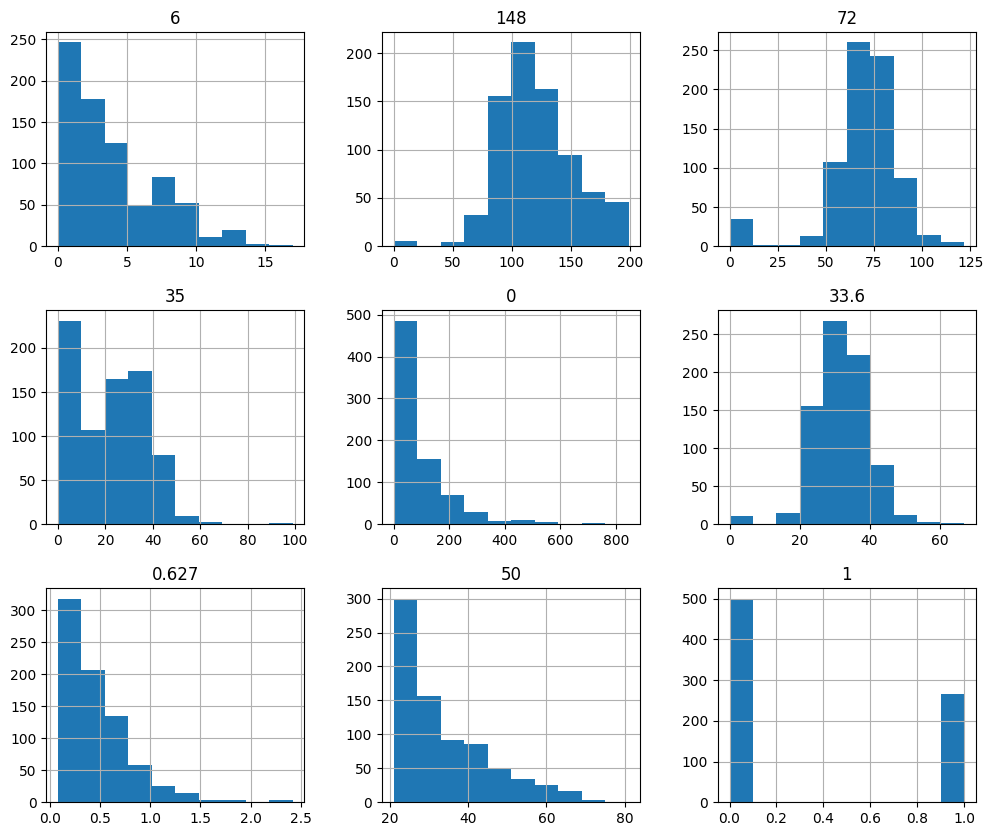

In [12]:
df.hist(figsize=(12,10))
plt.show()

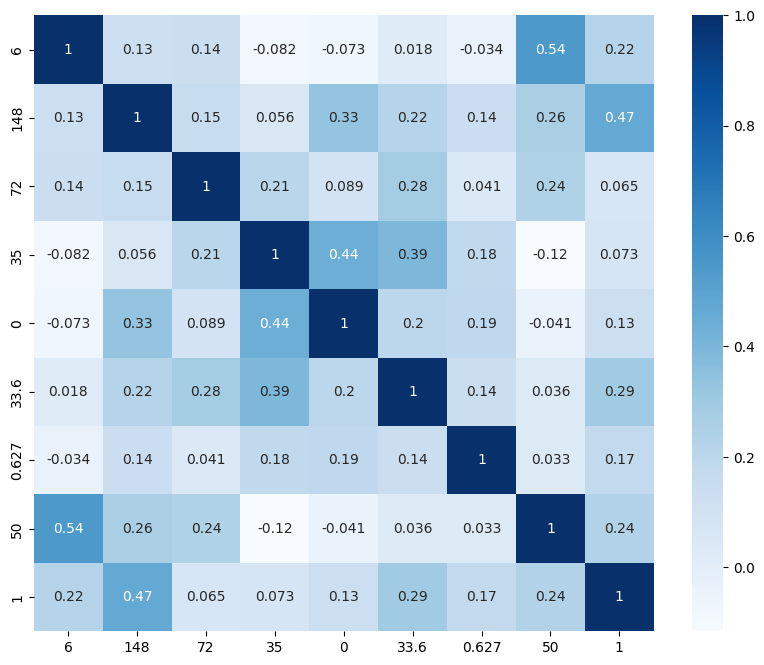

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()

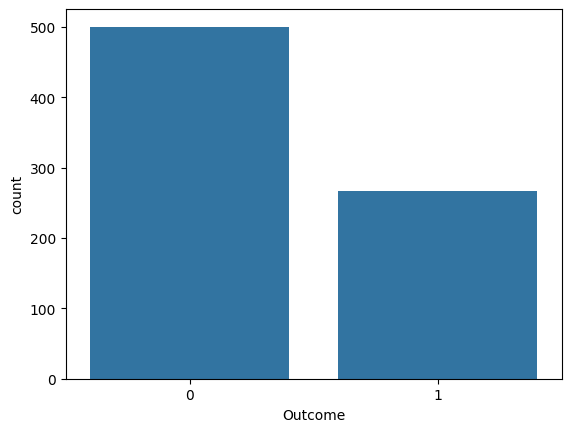

In [15]:
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df.columns = column_names
sns.countplot(x='Outcome',data=df)
plt.show()

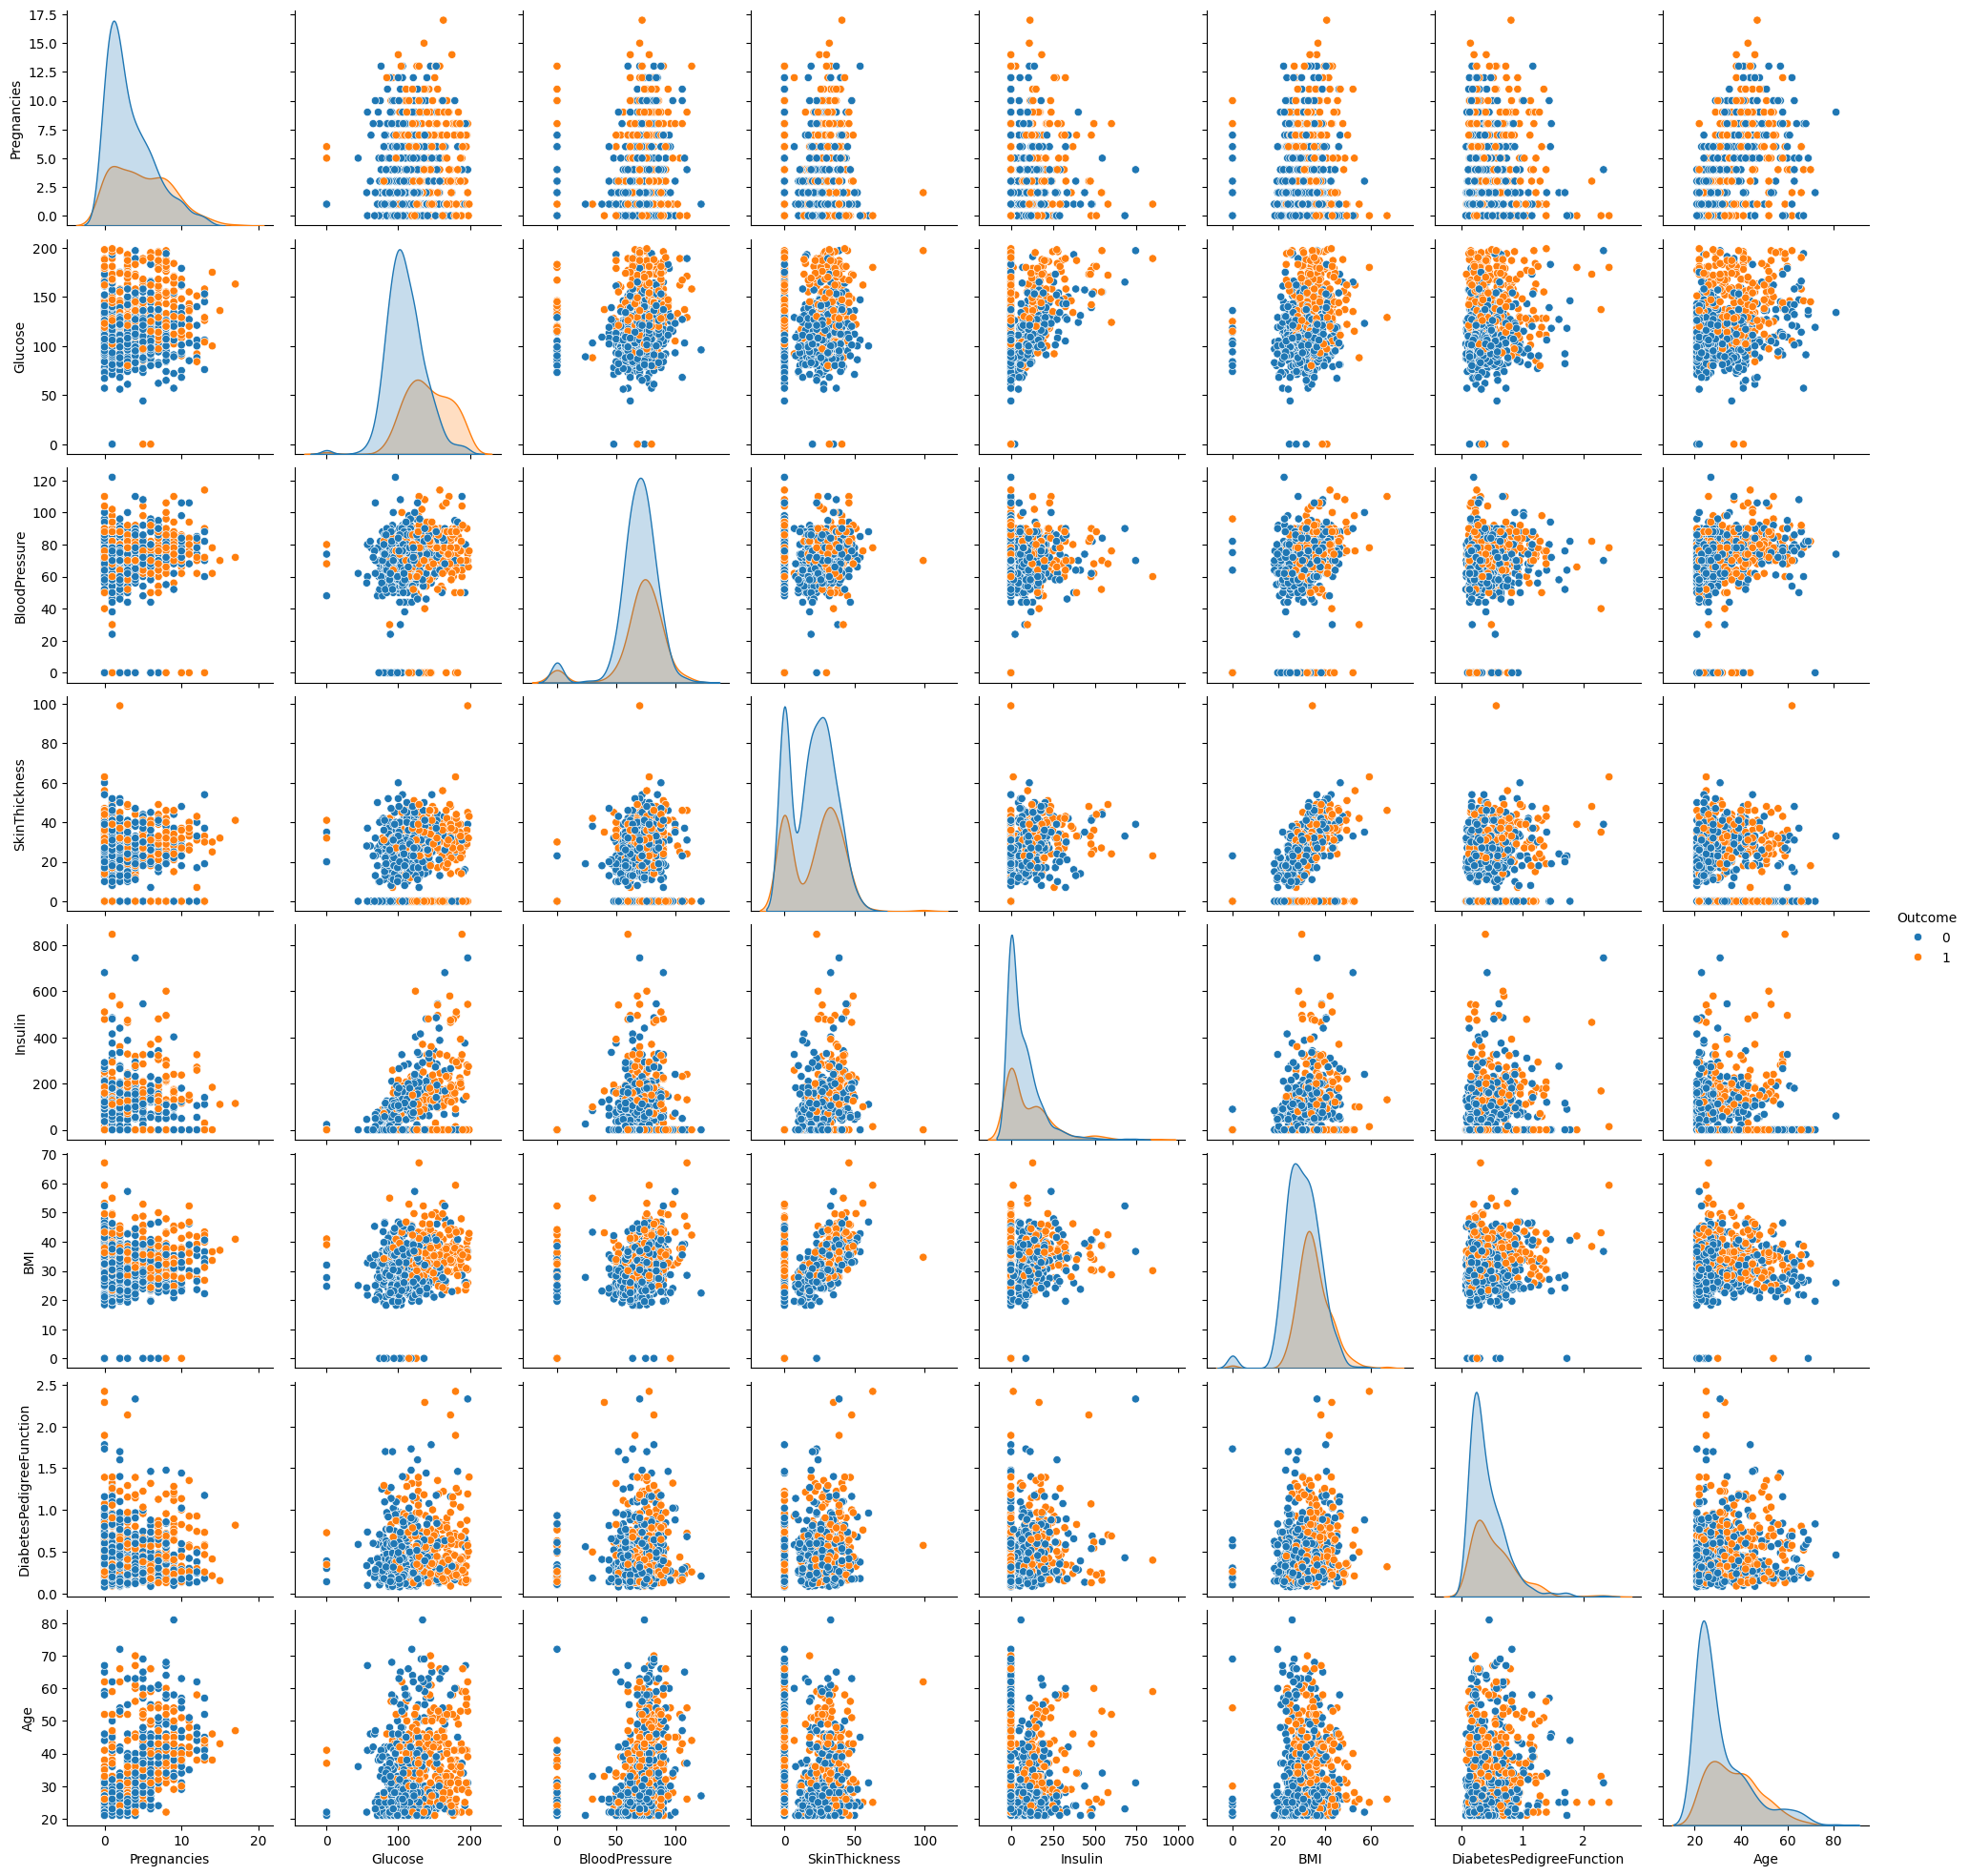

In [16]:
sns.pairplot(df,hue='Outcome')
plt.show()

In [17]:
X=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [20]:
def load_data(file):
    return pd.read_csv(file)

def clean_data(df):
    df=df.drop_duplicates()
    return df

def split_data(X,y):
    return train_test_split(X,y,test_size=0.2,random_state=42)

def train_model(model,X_train,y_train):
    model.fit(X_train,y_train)
    return model

def predict(model,data):
    return model.predict(data)

def save_model(model,name):
    joblib.dump(model,name)

In [21]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

In [22]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_pred=knn.predict(X_test)

In [23]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred=dt.predict(X_test)

In [24]:
def evaluate(name,y_test,pred):

    print(name)

    print("Accuracy:",accuracy_score(y_test,pred))

    print("Precision:",precision_score(y_test,pred))

    print("Recall:",recall_score(y_test,pred))

    print("F1 Score:",f1_score(y_test,pred))

    print("Confusion Matrix")

    print(confusion_matrix(y_test,pred))

    print("-"*40)

In [25]:
evaluate("Logistic Regression",y_test,lr_pred)

evaluate("KNN",y_test,knn_pred)

evaluate("Decision Tree",y_test,dt_pred)

Logistic Regression
Accuracy: 0.8116883116883117
Precision: 0.7916666666666666
Recall: 0.6666666666666666
F1 Score: 0.7238095238095238
Confusion Matrix
[[87 10]
 [19 38]]
----------------------------------------
KNN
Accuracy: 0.7272727272727273
Precision: 0.6595744680851063
Recall: 0.543859649122807
F1 Score: 0.5961538461538461
Confusion Matrix
[[81 16]
 [26 31]]
----------------------------------------
Decision Tree
Accuracy: 0.6883116883116883
Precision: 0.5737704918032787
Recall: 0.6140350877192983
F1 Score: 0.5932203389830508
Confusion Matrix
[[71 26]
 [22 35]]
----------------------------------------


In [26]:
save_model(lr,"diabetes_model.pkl")

In [27]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [29]:
from google.colab import files

files.download("diabetes_model.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
preg = 6
glu = 148
bp = 72
skin = 35
ins = 0
bmi = 33.6
dpf = 0.627
age = 50

new_data=np.array([[preg,glu,bp,skin,ins,bmi,dpf,age]])

new_data=scaler.transform(new_data)

prediction=lr.predict(new_data)

if prediction[0]==1:
    print("Diabetic")
else:
    print("Not Diabetic")

Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
